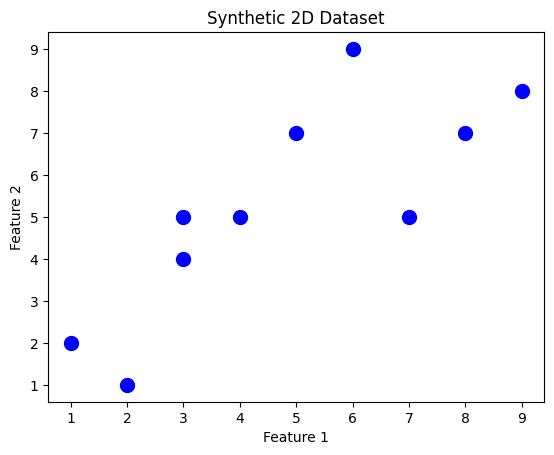

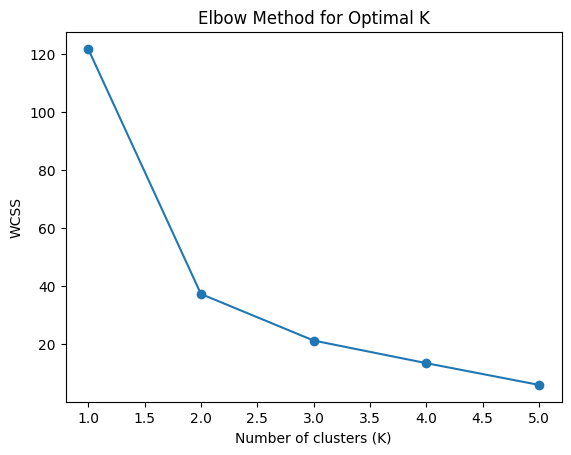

Elbow point: Look for the 'bend' in the plot to select optimal K (around 3 here).


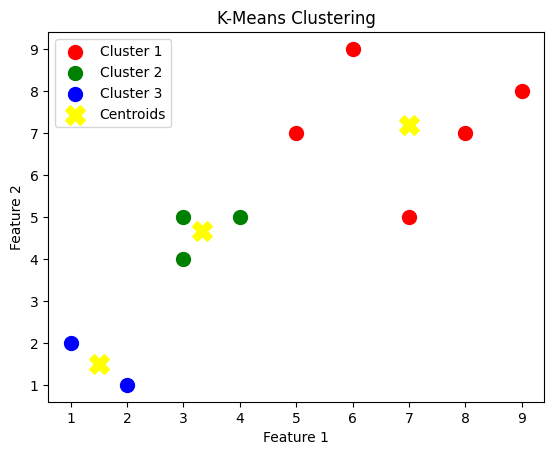

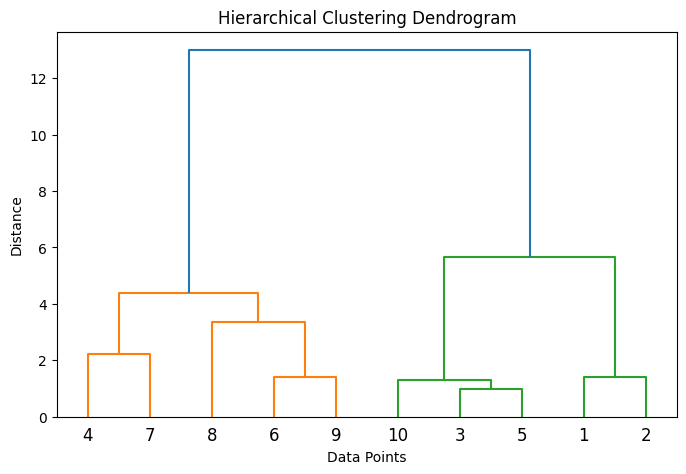

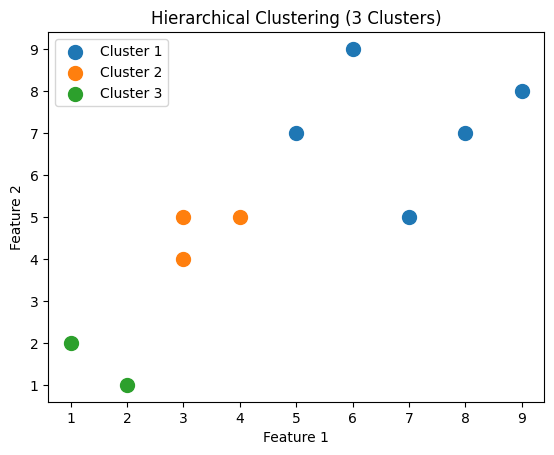

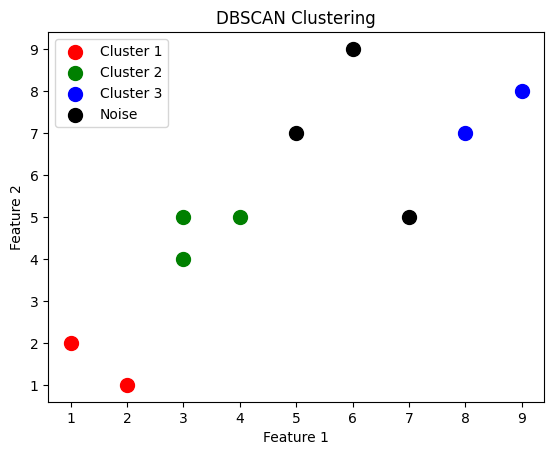


Observations:
- K-Means: Good for spherical, well-separated clusters. Needs K beforehand. Sensitive to outliers.
- Hierarchical: Builds a tree, no need to specify K initially. Can capture nested clusters. Slow for large datasets.
- DBSCAN: Finds clusters of arbitrary shape, automatically identifies noise. Needs careful tuning of eps and min_samples. Cannot handle varying densities well.



In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ---------------------------
# 1. Create a small synthetic dataset
# ---------------------------
np.random.seed(42)  # For reproducibility
# 10 two-dimensional points
data = np.array([
    [1, 2],
    [2, 1],
    [3, 4],
    [5, 7],
    [3, 5],
    [8, 7],
    [6, 9],
    [7, 5],
    [9, 8],
    [4, 5]
])

# ---------------------------
# 2. Visualize the dataset
# ---------------------------
plt.scatter(data[:,0], data[:,1], color='blue', s=100)
plt.title("Synthetic 2D Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# ---------------------------
# 3. & 4. Elbow Method for K-Means
# ---------------------------
wcss = []
K_values = range(1,6)
for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)  # WCSS = sum of squared distances to centroids

# Plot WCSS vs K
plt.plot(K_values, wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.show()

# Observation:
print("Elbow point: Look for the 'bend' in the plot to select optimal K (around 3 here).")

# ---------------------------
# 5. K-Means Clustering with 3 clusters
# ---------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(data)
centroids = kmeans.cluster_centers_

# ---------------------------
# 6. Plot K-Means clusters
# ---------------------------
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.scatter(data[labels_kmeans == i, 0], data[labels_kmeans == i, 1], 
                color=colors[i], s=100, label=f'Cluster {i+1}')
plt.scatter(centroids[:,0], centroids[:,1], color='yellow', s=200, marker='X', label='Centroids')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# ---------------------------
# 7. Hierarchical Clustering using Ward method
# ---------------------------
linked = linkage(data, method='ward')

# ---------------------------
# 8. Plot dendrogram
# ---------------------------
plt.figure(figsize=(8, 5))
dendrogram(linked, labels=np.arange(1, len(data)+1))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# ---------------------------
# 9. Assign clusters from dendrogram (3 clusters)
# ---------------------------
labels_hier = fcluster(linked, t=3, criterion='maxclust')

# Plot Hierarchical clusters
for i in range(1, 4):
    plt.scatter(data[labels_hier == i, 0], data[labels_hier == i, 1], 
                s=100, label=f'Cluster {i}')
plt.title("Hierarchical Clustering (3 Clusters)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# ---------------------------
# 10. DBSCAN Clustering
# ---------------------------
dbscan = DBSCAN(eps=2.0, min_samples=2)
labels_dbscan = dbscan.fit_predict(data)

# ---------------------------
# 11. Plot DBSCAN clusters
# ---------------------------
unique_labels = set(labels_dbscan)
for lbl in unique_labels:
    if lbl == -1:
        # Noise points
        color = 'black'
        label_name = 'Noise'
    else:
        color = colors[lbl % 3]
        label_name = f'Cluster {lbl+1}'
    plt.scatter(data[labels_dbscan == lbl, 0], data[labels_dbscan == lbl, 1], 
                color=color, s=100, label=label_name)
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# ---------------------------
# 12. Observations and Comparison
# ---------------------------
print("""
Observations:
- K-Means: Good for spherical, well-separated clusters. Needs K beforehand. Sensitive to outliers.
- Hierarchical: Builds a tree, no need to specify K initially. Can capture nested clusters. Slow for large datasets.
- DBSCAN: Finds clusters of arbitrary shape, automatically identifies noise. Needs careful tuning of eps and min_samples. Cannot handle varying densities well.
""")
